# Object Recognition with CNNs

In this notebook we will create a set of CNN models trained on the CIFAR-10 dataset to establish a comparison between different convolutional model configurations. Particularily, we will focus on module architecture rather than other hyperparameters like epoch, learning rate, the selected optimizer, etc.

In [105]:
import torch.nn as nn
import pandas as pd
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [106]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

## Load data

Using the CIFAR-10 dataset bundled with torchvision (https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html#torchvision.datasets.CIFAR10):

Nota: _To convert the data to `PIL.Image`, pytorch allows making "transforms" upon loading them. (https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.ToTensor.html?highlight=totensor#torchvision.transforms.ToTensor)_

In [107]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

c:\Users\PC\Desktop\cetys-icc-compint\.conda\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


We will avoid creating a validation set as per the instructions of the exercise. The split is already made:
- `train` with `50,000` entries
- `test` with `10,000` entries

In [108]:
print(f"Train: {len(train_data)}")
print(f"Test: {len(test_data)}")

Train: 50000
Test: 10000


We'll add some utility functions for visualization and interpretation.

For display an image, we select the first channel (the only channel). For obtaining its label, `Dataset` from pytorch has a `classes` parameter we can access that has each label at its index.

We call `permute` on the image to reorder the dimensions of the data so matplotlib can properly render them.

In [109]:
def show_example(img, label):
    plt.imshow(img.permute(1, 2, 0), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()

def get_letter(label):
    return train_data.classes[label]

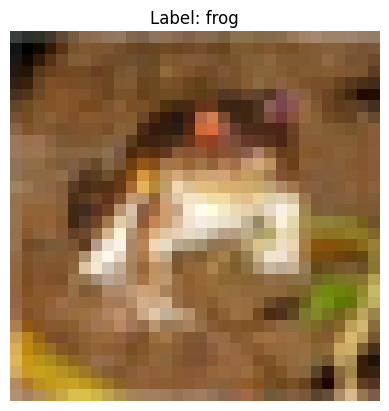

In [110]:
img, label = train_data[0]
show_example(img, get_letter(label))

## Dataset Preparation

It was specified in the exercise's instructions we do **not** need to use *validation*.

Since we are already using a pytorch `Dataset` (CIFAR-10), we just need to pass it to a dataloader, and indicate that the batch size is `32` so it partitions it accordinly.

In [111]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)

## Training Function

Taken from my previous exercise, with some modifications to support mini batches and appending accuracy to evaluation, these are the functions that will aid in training our model.

The batch accuracy is calculated by dividing the amount of correct predictions over the amount of predictions made, ON THIS BATCH ONLY.

In [112]:
def batch_accuracy(output, y, batch_size):
    predicted = output.argmax(dim=1)
    correct = (predicted == y).sum().item()
    return correct / batch_size

For evaluation, we make a summation of the loss and accuracy of all batches, then divide them over the amount of batches to get the average loss and accuracy for this epoch.

In [113]:
def evaluate(model, loss_fn, val_loader):
    model.eval()
    loss = 0
    accuracy = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            val_outputs = model(batch_x.to(device))
            val_loss = loss_fn(val_outputs, batch_y.to(device))
            loss += val_loss.item()
            accuracy += batch_accuracy(val_outputs, batch_y.to(device).long(), batch_x.shape[0])
    return (loss / len(val_loader), accuracy / len(val_loader))

The learning curve merely takes in a tuple `(train_hist, val_hist)`, and each object is a tuple of `(loss, accuracy)`, then plots both the curve for loss and accuracy.

In [114]:
def learning_curve(history):
    train_hist, val_hist = history
    train_loss = [t[0] for t in train_hist] # el [0] siempre es el
    val_loss   = [v[0] for v in val_hist]
    train_acc  = [t[1] for t in train_hist] # el [1] siempre es el accuracy
    val_acc    = [v[1] for v in val_hist]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(train_loss, label="Train Loss")
    ax1.plot(val_loss, label="Val Loss")
    ax1.set_title("Loss Curve")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()

    ax2.plot(train_acc, label="Train Accuracy")
    ax2.plot(val_acc, label="Val Accuracy")
    ax2.set_title("Accuracy Curve")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()

    plt.show()

Training is done in the following steps: 
- Start training
- Iterate over `N` amount of epochs
- Each epoch will iterate over `N` amount of batches (`32`)
- Each batch updates the weights after computing the gradients (after resetting them)
- After the epoch finishes with the mini batches, the model is evaluated against using `evaluate` (from above) against the validation set (test, in this case)

For organization and separation-of-concerns purposes, the learning curve for each training session is output manually after each model is trained, not in the training function.

In [115]:
def train(model, optimizer, loss_fn, train_loader, val_loader, epochs=10, batch_size=32, delta=0.005, patience=3):
    val_hist = []
    train_hist = []

    # for each epoch
    for epoch in range(epochs):
        # we train the model
        model.train()

        # loop over mini batches
        train_loss = 0
        train_accuracy = 0
        for batch_x, batch_y in train_loader:
            # compute outputs to measure the loss (forward pass)
            outputs = model(batch_x)
            loss = loss_fn(outputs, batch_y)

            # reset the GRADIENTS to zero
            optimizer.zero_grad()

            # compute the GRADIENTS (backward pass)
            loss.backward()

            # update the WEIGHTS, as they were modified by the backward pass
            # this is what persists across iterations and epochs
            optimizer.step()

            # we save the training loss for this batch
            train_loss += loss.item() * batch_x.shape[0]
            train_accuracy += batch_accuracy(outputs, batch_y.long(), batch_x.shape[0])

        train_hist.append((train_loss / len(train_loader.dataset), train_accuracy / len(train_loader)))

        # then we evaluate the model on the validation set
        eval = evaluate(model, loss_fn, val_loader)
        val_hist.append(eval)

        val_loss, val_acc = eval
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

        # early stopping
        if len(val_hist) > patience:
            loss_n_patience = val_hist[-patience-1][0] # [0] es el loss
            loss_n = val_hist[-1][0]
            current_delta = abs(loss_n_patience - loss_n)
            if current_delta < delta and loss_n_patience >= loss_n:
                print(f"Early stopping at epoch {epoch+1}")
                break

    return train_hist, val_hist

## Model Definition & Training

Now, we will define the parameters of our models, before we come up with an appropriate architecture for them.

Since CIFAR provides images of size `32x32`, we will use that size (flattened) as the input of each one of the models. Additionally, we will be working with 3 channels (as stated above when we loaded the dataset).

In [116]:
IMG_WIDTH = 32
IMG_HEIGHT = 32
IMG_CHANNELS = 3

The amount of epochs to train the models on is `20`, and the loss function is `Cross Entropy`.

Particularily, we choose Cross Entropy because we have multiple classes in the prediction pool.

The optimizer to be used is **Adam**, which will be created for each model.

In [117]:
epochs = 20
loss_function = nn.CrossEntropyLoss()

### CNN Model 1

The first model's architecture is as follows:
- Layer 1: Convolutional (Conv2d)
  - Input channels: IMG_CHANNELS
  - Output channels: 25
  - Kernel size: 3x3
  - Stride: 1
  - Padding: 1
  - Output shape: 25 x 32 x 32

- Layer 2: Activation (ReLU)

- Layer 3: Pooling (MaxPool2d)
  - Kernel size: 2x2
  - Stride: 2
  - Downsamples
  - Output shape: 25 x 16 x 16

- Layer 4: Flatten
  - Converts 3D into 1D vector
  - Output shape: 25 x 16 x 16 = 6400

- Layer 5: Fully Connected (Linear)
  - Input: 6400
  - Output: 24

In [118]:
model_1 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 16 x 16

    nn.Flatten(),
    nn.Linear(25 * 16 * 16, 10)  # 10 output classes for CIFAR-10
)

model_1 = model_1.to(device)

In [119]:
optim_1 = torch.optim.Adam(model_1.parameters(), lr=0.001)

In [120]:
model_1_train = train(model_1, optim_1, loss_function, train_loader, test_loader, epochs=epochs)

Epoch 1/20, Loss: 1.4612, Val Loss: 1.2812, Val Acc: 0.5541
Epoch 2/20, Loss: 1.1656, Val Loss: 1.1990, Val Acc: 0.5842
Epoch 3/20, Loss: 0.8955, Val Loss: 1.1748, Val Acc: 0.5917
Epoch 4/20, Loss: 0.9355, Val Loss: 1.0976, Val Acc: 0.6186
Epoch 5/20, Loss: 0.6452, Val Loss: 1.1194, Val Acc: 0.6107
Epoch 6/20, Loss: 0.7016, Val Loss: 1.1071, Val Acc: 0.6166
Epoch 7/20, Loss: 0.8655, Val Loss: 1.1015, Val Acc: 0.6144
Epoch 8/20, Loss: 0.9176, Val Loss: 1.0819, Val Acc: 0.6290
Epoch 9/20, Loss: 0.7085, Val Loss: 1.0565, Val Acc: 0.6420
Epoch 10/20, Loss: 0.7427, Val Loss: 1.0685, Val Acc: 0.6324
Epoch 11/20, Loss: 0.4806, Val Loss: 1.0934, Val Acc: 0.6247
Epoch 12/20, Loss: 0.6792, Val Loss: 1.1110, Val Acc: 0.6331
Epoch 13/20, Loss: 0.8939, Val Loss: 1.1419, Val Acc: 0.6219
Epoch 14/20, Loss: 1.1799, Val Loss: 1.1460, Val Acc: 0.6209
Epoch 15/20, Loss: 0.7111, Val Loss: 1.1010, Val Acc: 0.6351
Epoch 16/20, Loss: 0.6386, Val Loss: 1.1968, Val Acc: 0.6209
Epoch 17/20, Loss: 0.6794, Val Lo

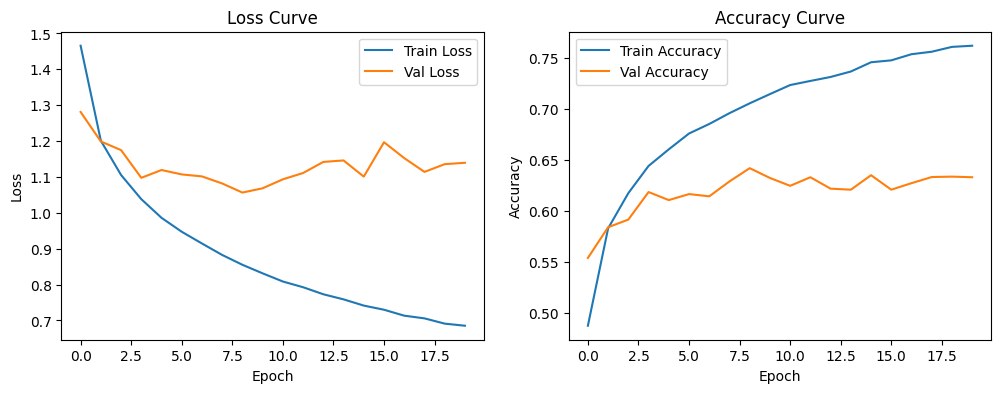

In [121]:
learning_curve(model_1_train)

### CNN Model 2

The second model's architecture is as follows:

- Layer 1: Convolutional (Conv2d)
  - Input channels: IMG_CHANNELS
  - Output channels: 25
  - Kernel size: 3x3
  - Stride: 1
  - Padding: 1
  - Output shape: 25 x 32 x 32

- Layer 2: Activation (ReLU)

- Layer 3: Pooling (MaxPool2d)
  - Kernel size: 2x2
  - Stride: 2
  - Downsamples
  - Output shape: 25 x 16 x 16

- Layer 4: Convolutional (Conv2d)
  - Input channels: 25
  - Output channels: 50
  - Kernel size: 3x3
  - Stride: 1
  - Padding: 1
  - Output shape: 50 x 16 x 16

- Layer 5: Activation (ReLU)

- Layer 6: MaxPool2d
  - Kernel size: 2x2
  - Stride: 2
  - Downsamples
  - Output shape: 50 x 8 x 8

- Layer 7: Flatten
  - Converts 3D maps into 1D vector
  - Output shape: 50 x 8 x 8 = 3200

- Layer 8: Output
  - Input: 3200
  - Output: 24

In [122]:
model_2 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 16 x 16

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 16 x 16
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 50 x 8 x 8

    nn.Flatten(),
    nn.Linear(50 * 8 * 8, 10)  # 10 output classes for CIFAR-10
)

model_2 = model_2.to(device)

In [123]:
optim_2 = torch.optim.Adam(model_2.parameters(), lr=0.001)

In [124]:
model_2_train = train(model_2, optim_2, loss_function, train_loader, test_loader, epochs=epochs)

Epoch 1/20, Loss: 1.4207, Val Loss: 1.2058, Val Acc: 0.5786
Epoch 2/20, Loss: 1.0789, Val Loss: 1.0913, Val Acc: 0.6057
Epoch 3/20, Loss: 0.8140, Val Loss: 1.0170, Val Acc: 0.6415
Epoch 4/20, Loss: 1.0700, Val Loss: 0.9871, Val Acc: 0.6551
Epoch 5/20, Loss: 1.0735, Val Loss: 0.9268, Val Acc: 0.6789
Epoch 6/20, Loss: 0.8104, Val Loss: 0.9225, Val Acc: 0.6814
Epoch 7/20, Loss: 1.1800, Val Loss: 0.8926, Val Acc: 0.6945
Epoch 8/20, Loss: 0.7810, Val Loss: 0.9220, Val Acc: 0.6832
Early stopping at epoch 8


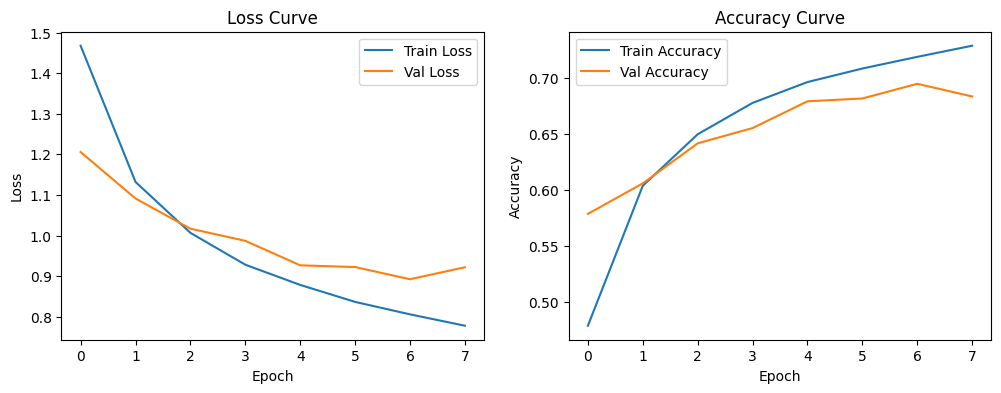

In [125]:
learning_curve(model_2_train)

### CNN Model 3

The third model's:

- Layer 1: Convolutional (Conv2d)
  - Input channels: IMG_CHANNELS
  - Output channels: 25
  - Kernel size: 3x3
  - Stride: 1
  - Padding: 1
  - Output shape: 25 x 32 x 32

- Layer 2: Activation (ReLU)

- Layer 3: MaxPool2d
  - Kernel size: 2x2
  - Stride: 2
  - Downsamples
  - Output shape: 25 x 16 x 16

- Layer 4: Convolutional (Conv2d)
  - Input channels: 25
  - Output channels: 50
  - Kernel size: 3x3
  - Stride: 1
  - Padding: 1
  - Output shape: 50 x 16 x 16

- Layer 5: Activation (ReLU)

- Layer 6: MaxPool2d
  - Kernel size: 2x2
  - Stride: 2
  - Downsamples
  - Output shape: 50 x 8 x 8

- Layer 7: Flatten
  - Converts 3D into 1D vector
  - Output shape: 50 x 8 x 8 = 3200

- Layer 8: Dense
  - Input: 3200
  - Output: 128

- Layer 9: Activation (ReLU)

- Layer 10: Output
  - Input: 128
  - Output: 24

This model is similar to the second model, except it has an additional dense layer.

In [126]:
model_3 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 16 x 16

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 16 x 16
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 50 x 8 x 8

    nn.Flatten(),
    nn.Linear(50 * 8 * 8, 128),
    nn.ReLU(),
    nn.Linear(128, 10)  # 10 output classes for CIFAR-10
)

model_3 = model_3.to(device)

In [127]:
optim_3 = torch.optim.Adam(model_3.parameters(), lr=0.001)

In [128]:
model_3_train = train(model_3, optim_3, loss_function, train_loader, test_loader, epochs=epochs)

Epoch 1/20, Loss: 1.2321, Val Loss: 1.2178, Val Acc: 0.5663
Epoch 2/20, Loss: 0.6625, Val Loss: 1.0310, Val Acc: 0.6339
Epoch 3/20, Loss: 0.8815, Val Loss: 0.9667, Val Acc: 0.6577
Epoch 4/20, Loss: 0.9859, Val Loss: 0.9441, Val Acc: 0.6670
Epoch 5/20, Loss: 1.0994, Val Loss: 0.8911, Val Acc: 0.6906
Epoch 6/20, Loss: 0.9312, Val Loss: 0.8938, Val Acc: 0.6969
Epoch 7/20, Loss: 0.7942, Val Loss: 0.9104, Val Acc: 0.6906
Epoch 8/20, Loss: 0.9403, Val Loss: 0.9009, Val Acc: 0.6963
Epoch 9/20, Loss: 0.9401, Val Loss: 0.9344, Val Acc: 0.6912
Epoch 10/20, Loss: 1.2196, Val Loss: 0.9762, Val Acc: 0.6923
Epoch 11/20, Loss: 0.5066, Val Loss: 0.9660, Val Acc: 0.7037
Epoch 12/20, Loss: 0.3231, Val Loss: 1.0219, Val Acc: 0.6929
Epoch 13/20, Loss: 0.6106, Val Loss: 1.0969, Val Acc: 0.6903
Epoch 14/20, Loss: 0.0796, Val Loss: 1.1367, Val Acc: 0.6901
Epoch 15/20, Loss: 0.1797, Val Loss: 1.1899, Val Acc: 0.6909
Epoch 16/20, Loss: 0.2374, Val Loss: 1.4112, Val Acc: 0.6660
Epoch 17/20, Loss: 0.0414, Val Lo

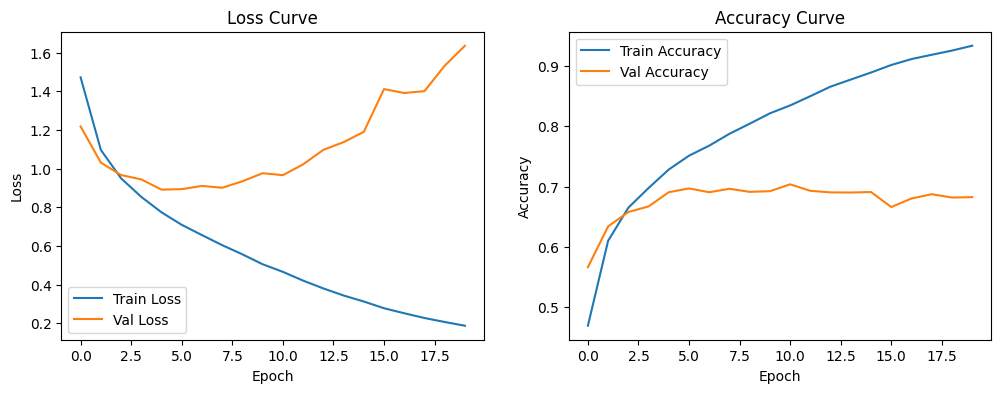

In [129]:
learning_curve(model_3_train)

## Model Evaluation

To evaluate the models and compare their performance, we can call the `evaluate` function we made earlier. In practice, only now would we actually care to use the `test` set and evaluate the best model, but since there is no validation set, the performance metrics we get here are likely to be the ones from the validation phase in training.

In [130]:
models = [model_1, model_2, model_3]
model_histories = [model_1_train, model_2_train, model_3_train]

eval = {
    "Model 1": evaluate(model_1, loss_function, test_loader),
    "Model 2": evaluate(model_2, loss_function, test_loader),
    "Model 3": evaluate(model_3, loss_function, test_loader),
}

best_model_idx = -1
best_model = None
best_acc = -1
best_loss = None
best_model_train = None

for idx, (model_name, (loss, acc)) in enumerate(eval.items()):
    print(f"{model_name} - Loss: {loss:.4f}, Accuracy: {acc:.4f}")
    if acc > best_acc:
        best_model_idx = idx
        best_model = models[idx]
        best_model_train = model_histories[idx]
        best_acc = acc
        best_loss = loss

print(f"Best model: Model {best_model_idx + 1}")
print(f"Accuracy: {best_acc:.4f}")
print(f"Loss: {best_loss:.4f}")

Model 1 - Loss: 1.1395, Accuracy: 0.6331
Model 2 - Loss: 0.9220, Accuracy: 0.6832
Model 3 - Loss: 1.6354, Accuracy: 0.6824
Best model: Model 2
Accuracy: 0.6832
Loss: 0.9220


The best model is the one selected programmatically in the previous cell based on the highest test accuracy.

Its accuracy and loss are:

In [131]:
results = evaluate(best_model, loss_function, test_loader)
best_model_loss = results[0]
best_model_accuracy = results[1]
print(f"Best model accuracy on test set: {best_model_accuracy:.4f}")
print(f"Best model loss on test set: {best_model_loss:.4f}")

Best model accuracy on test set: 0.6832
Best model loss on test set: 0.9220


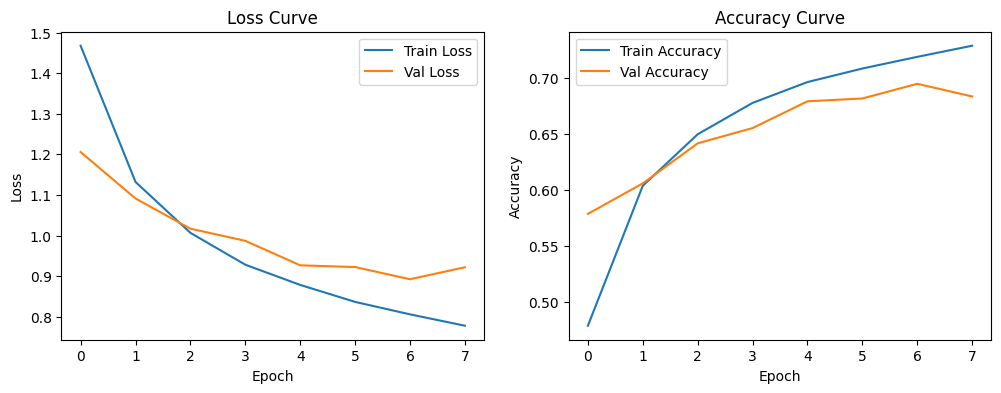

In [132]:
learning_curve(best_model_train)

## Extra Points

The user is able to classify their own image.

For this, we:
- Must read their image on disk
- Must preprocess the image and resize it accordingly
- Must use the best model
- Will output the classified label

In [133]:
from PIL import Image

To preprocess the images, we can use the transforms we used earlier to convert the dataset from PILImage, except the other way around.

- We need to resize them ([Resize](https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.Resize.html?highlight=resize#torchvision.transforms.Resize))
- We need to convert them to tensors ([ToTensor](https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.ToTensor.html?highlight=totensor#torchvision.transforms.ToTensor))

To load the image prior to preprocessing, we can call `Image.open` and assume it's RGB (it is). 

Then, to convert it to a tensor we can call our transformation pipeline. `unsqueeze` ensures that the shape of `[Channel, Height, Width]` becomes `[Batch, Channel, Height, Width]` where `Batch = 1` (because there are none).

Finally, the predicted label is that which has the highest probability score in the output array of the model (which is why we call `argmax`). We can use our `get_letter` function to convert the index to a proper label.

In [134]:
inference_transform = transforms.Compose([
    transforms.Resize((IMG_WIDTH, IMG_HEIGHT)),
    transforms.ToTensor(),
])

def classify_image(image_path, model=best_model):
    img = Image.open(image_path).convert("RGB")
    img_tensor = inference_transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        predicted_label = output.argmax(dim=1).item()

    return get_letter(predicted_label)

img_path = input("Enter the path of an image to classify: ")
predicted_label = classify_image(img_path)
print(f"Predicted label: {predicted_label}")

Predicted label: dog


## Final Remarks

Finally, the following remarks can be made from the notebook's results:

- A Convolutional Neural Network (CNN) does not guarantee excellente performance with image inputs. As can be seen, all three model performances were questionable at best. Particularily, this is due to the model's architecture and hyperparameters. The architecture was the only configuration aspect that changed across models, which is why a similar (albeit bad) performance was expected.

- Calculations for layer inputs and outputs are very important. A convolution layer whose output has a certain dimension and exact pixel count has to match the input of the next layer to allow for a proper pipeline execution.

- Downsampling with MaxPooling is benefitial to training execution, due to the dimensional reduction that it offers. It can cut down training time significantly, at the cost of model performance due to the missing data that it excludes from each pass.

- Transforms are imperative for preprocessing. Applying a transformation pipeline helps process the data in a way that the model is able to consume it, the same way it was trained on.

- The amount of channels in the image and accepted as an input in the model vastly matters in its performance. More channels means more data to learn patterns from. In contrast to previous models we've made that make use of a single channel, this model performs better by a couple percentile points.

From the learning curves:

- As training loss significantly decreases, its accuracy increases, as expected. However, validation loss increases or stabilizes (at best) causing an accuracy plataeu on most models, hindering real-world performance. This is why the test accuracy, at best, is around ~65%.

- The models seemingly overfit a bit toward the end, and perform worse on the validation/test set. This makes sense, as we have no additional validation set to train the model.


All in all, it's important to remember that a CNN model isn't one-size-fits-all. It helps learn patterns in a local space, vastly. However, it does not guarantee a top-tier performance, as its model configuration matters way more, alongside the data it is used to train on and the processing pipeline it undergoes.